# Module 2: Comprehensive Merged Data Analysis

This notebook performs detailed verification of all 7 metrics across all 27 containers before sequence generation.

## Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (16, 8)

print('✓ Libraries loaded')

✓ Libraries loaded


In [2]:
# Load merged data
possible_paths = [
    Path('./data/merged/training_data_normalized_merged.csv'),
    Path('../data/merged/training_data_normalized_merged.csv'),
    Path('/tmp/training_data_normalized_merged.csv'),
]

csv_path = None
for p in possible_paths:
    if p.exists():
        csv_path = p
        print(f'✓ Found CSV at: {csv_path}')
        break

if csv_path:
    df = pd.read_csv(csv_path)
    print(f'✓ Loaded {len(df):,} rows, {len(df.columns)} columns')
else:
    print('✗ CSV not found')

# Load normalization stats
stats_paths = [
    Path('./data/merged/normalization_stats.json'),
    Path('../data/merged/normalization_stats.json'),
    Path('/tmp/normalization_stats.json'),
]

stats_path = None
for p in stats_paths:
    if p.exists():
        stats_path = p
        with open(p) as f:
            norm_stats = json.load(f)
        print(f'✓ Loaded normalization stats from: {stats_path}')
        break

✓ Found CSV at: data\merged\training_data_normalized_merged.csv
✓ Loaded 533,338 rows, 11 columns
✓ Loaded normalization stats from: data\merged\normalization_stats.json


## Data Overview

In [3]:
print('='*80)
print('DATA STRUCTURE')
print('='*80)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

# Define all 7 metrics
all_metrics = [
    'container_cpu_usage_seconds_total',
    'container_cpu_system_seconds_total',
    'container_cpu_user_seconds_total',
    'container_memory_usage_bytes',
    'container_memory_working_set_bytes',
    'container_memory_rss',
    'container_memory_cache'
]

print(f'\nAll 7 Metrics: {len(all_metrics)}')
for i, m in enumerate(all_metrics, 1):
    print(f'  {i}. {m}')

print(f'\nFirst 5 rows:')
df.head(5)

DATA STRUCTURE
Shape: (533338, 11)
Columns: ['timestamp', 'case_source', 'cmdb_id', 'new_container_id', 'container_cpu_usage_seconds_total', 'container_cpu_system_seconds_total', 'container_cpu_user_seconds_total', 'container_memory_usage_bytes', 'container_memory_working_set_bytes', 'container_memory_rss', 'container_memory_cache']

All 7 Metrics: 7
  1. container_cpu_usage_seconds_total
  2. container_cpu_system_seconds_total
  3. container_cpu_user_seconds_total
  4. container_memory_usage_bytes
  5. container_memory_working_set_bytes
  6. container_memory_rss
  7. container_memory_cache

First 5 rows:


,timestamp,case_source,cmdb_id,new_container_id,container_cpu_usage_seconds_total,container_cpu_system_seconds_total,container_cpu_user_seconds_total,container_memory_usage_bytes,container_memory_working_set_bytes,container_memory_rss,container_memory_cache
0,1719223200,complex_case2,observe.cartservice-0,container_1,0.019471,0.224150,-0.085150,1.781805,1.937829,1.122773,1.937149
1,1719223200,complex_case2,observe.cartservice-1,container_2,0.018900,0.228312,-0.070982,3.262130,3.281267,1.218639,4.143833
2,1719223200,complex_case2,observe.cartservice-2,container_3,0.022336,0.198929,-0.095883,1.603348,1.692764,1.208077,1.620692
3,1719223200,complex_case2,observe.checkoutservice-0,container_4,-0.848146,-0.766129,-0.860932,-0.455347,-0.502588,-0.662535,-0.011717
4,1719223200,complex_case2,observe.checkoutservice-1,container_5,-0.848178,-0.787052,-0.870627,-0.680890,-0.718356,-0.567481,-0.404176


## All Metrics Statistics

In [4]:
print('='*120)
print('COMPLETE METRICS STATISTICS (Per-Case Normalized)')
print('='*120)
print(f'{"Metric":<40s} {"Mean":>12s} {"Std":>12s} {"Min":>12s} {"Max":>12s} {"Non-Null":>12s}')
print('-'*120)

stats_summary = {}
for metric in all_metrics:
    if metric in df.columns:
        mean = df[metric].mean()
        std = df[metric].std()
        min_val = df[metric].min()
        max_val = df[metric].max()
        non_null = df[metric].notna().sum()
        
        stats_summary[metric] = {'mean': mean, 'std': std, 'min': min_val, 'max': max_val}
        
        print(f'{metric:<40s} {mean:12.4f} {std:12.4f} {min_val:12.4f} {max_val:12.4f} {non_null:12,d}')
    else:
        print(f'{metric:<40s} [NOT FOUND]')

print('\n✓ All metrics are normalized with z-score (mean ≈ 0, std ≈ 1)')

COMPLETE METRICS STATISTICS (Per-Case Normalized)
Metric                                           Mean          Std          Min          Max     Non-Null
------------------------------------------------------------------------------------------------------------------------
container_cpu_usage_seconds_total             -0.0000       1.0000      -1.0114       4.4310      533,338
container_cpu_system_seconds_total            -0.0000       1.0000      -0.9782       4.8156      533,338
container_cpu_user_seconds_total               0.0000       1.0000      -0.9875       4.3544      533,338
container_memory_usage_bytes                   0.0000       1.0000      -4.1881       6.7046      533,338
container_memory_working_set_bytes            -0.0000       1.0000      -4.2719       7.0281      533,338
container_memory_rss                           0.0000       1.0000      -6.9985      11.2656      533,338
container_memory_cache                         0.0000       1.0000      -0.7905       6

## Case Distribution


Rows per Case:
  complex_case1  : 318,445 ( 59.7%)
  complex_case2  :  94,932 ( 17.8%)
  single_case1   :  74,223 ( 13.9%)
  single_case2   :  45,738 (  8.6%)


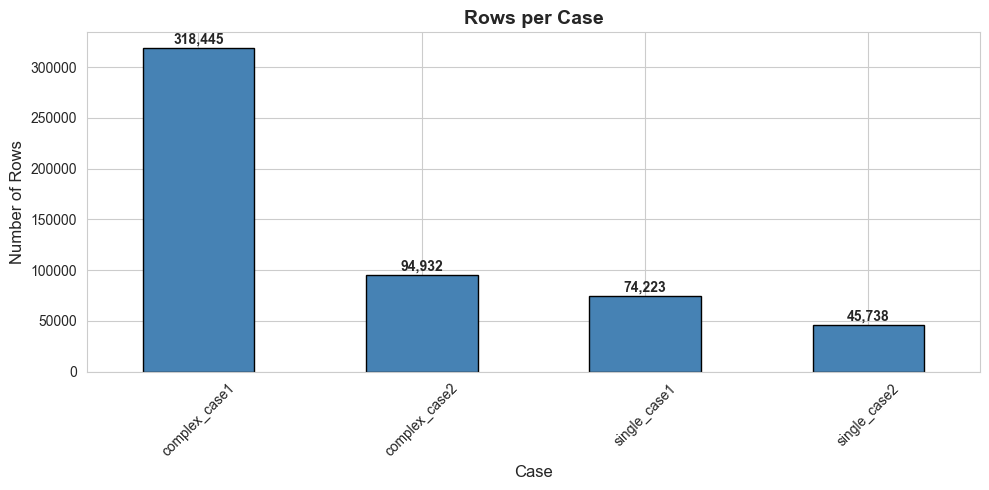

In [5]:
case_counts = df['case_source'].value_counts().sort_index()
print('\nRows per Case:')
for case, count in case_counts.items():
    pct = (count / len(df)) * 100
    print(f'  {case:15s}: {count:7,d} ({pct:5.1f}%)')

fig, ax = plt.subplots(figsize=(10, 5))
case_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Rows per Case', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Rows', fontsize=12)
ax.set_xlabel('Case', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(case_counts):
    ax.text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Container Distribution


Unique containers: 27
Rows per container (should be consistent for each container):
  Min: 18,397
  Max: 37,434
  Mean: 19,753


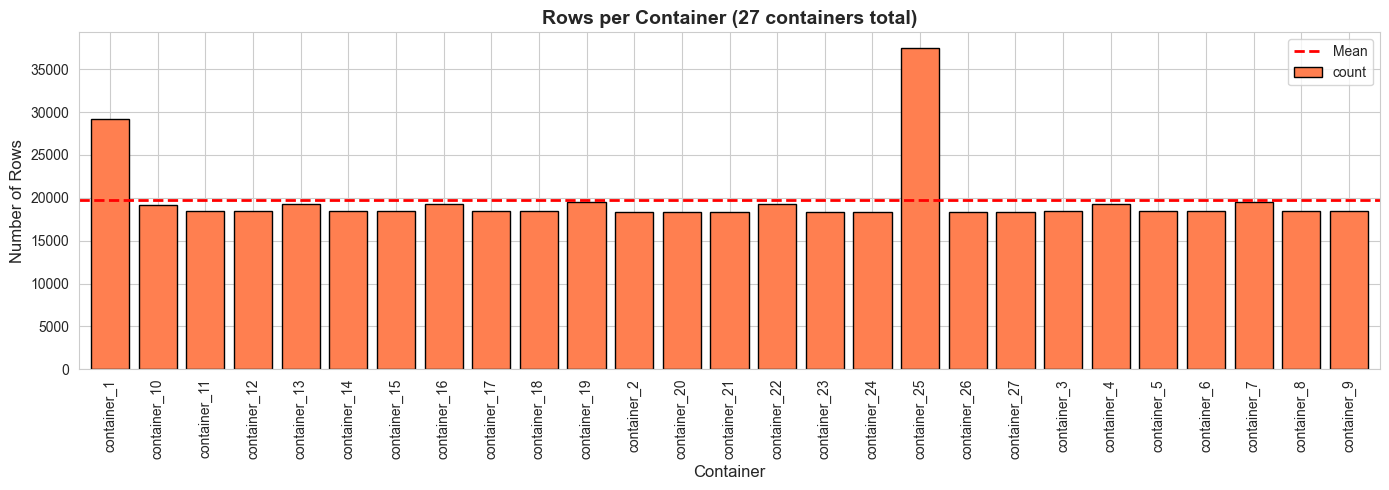

In [6]:
container_counts = df['new_container_id'].value_counts().sort_index()
print(f'\nUnique containers: {len(container_counts)}')
print(f'Rows per container (should be consistent for each container):' )
print(f'  Min: {container_counts.min():,}')
print(f'  Max: {container_counts.max():,}')
print(f'  Mean: {container_counts.mean():,.0f}')

fig, ax = plt.subplots(figsize=(14, 5))
container_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='black', width=0.8)
ax.set_title('Rows per Container (27 containers total)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Rows', fontsize=12)
ax.set_xlabel('Container', fontsize=12)
ax.axhline(container_counts.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
ax.legend()
plt.tight_layout()
plt.show()

## Feature Distribution Analysis

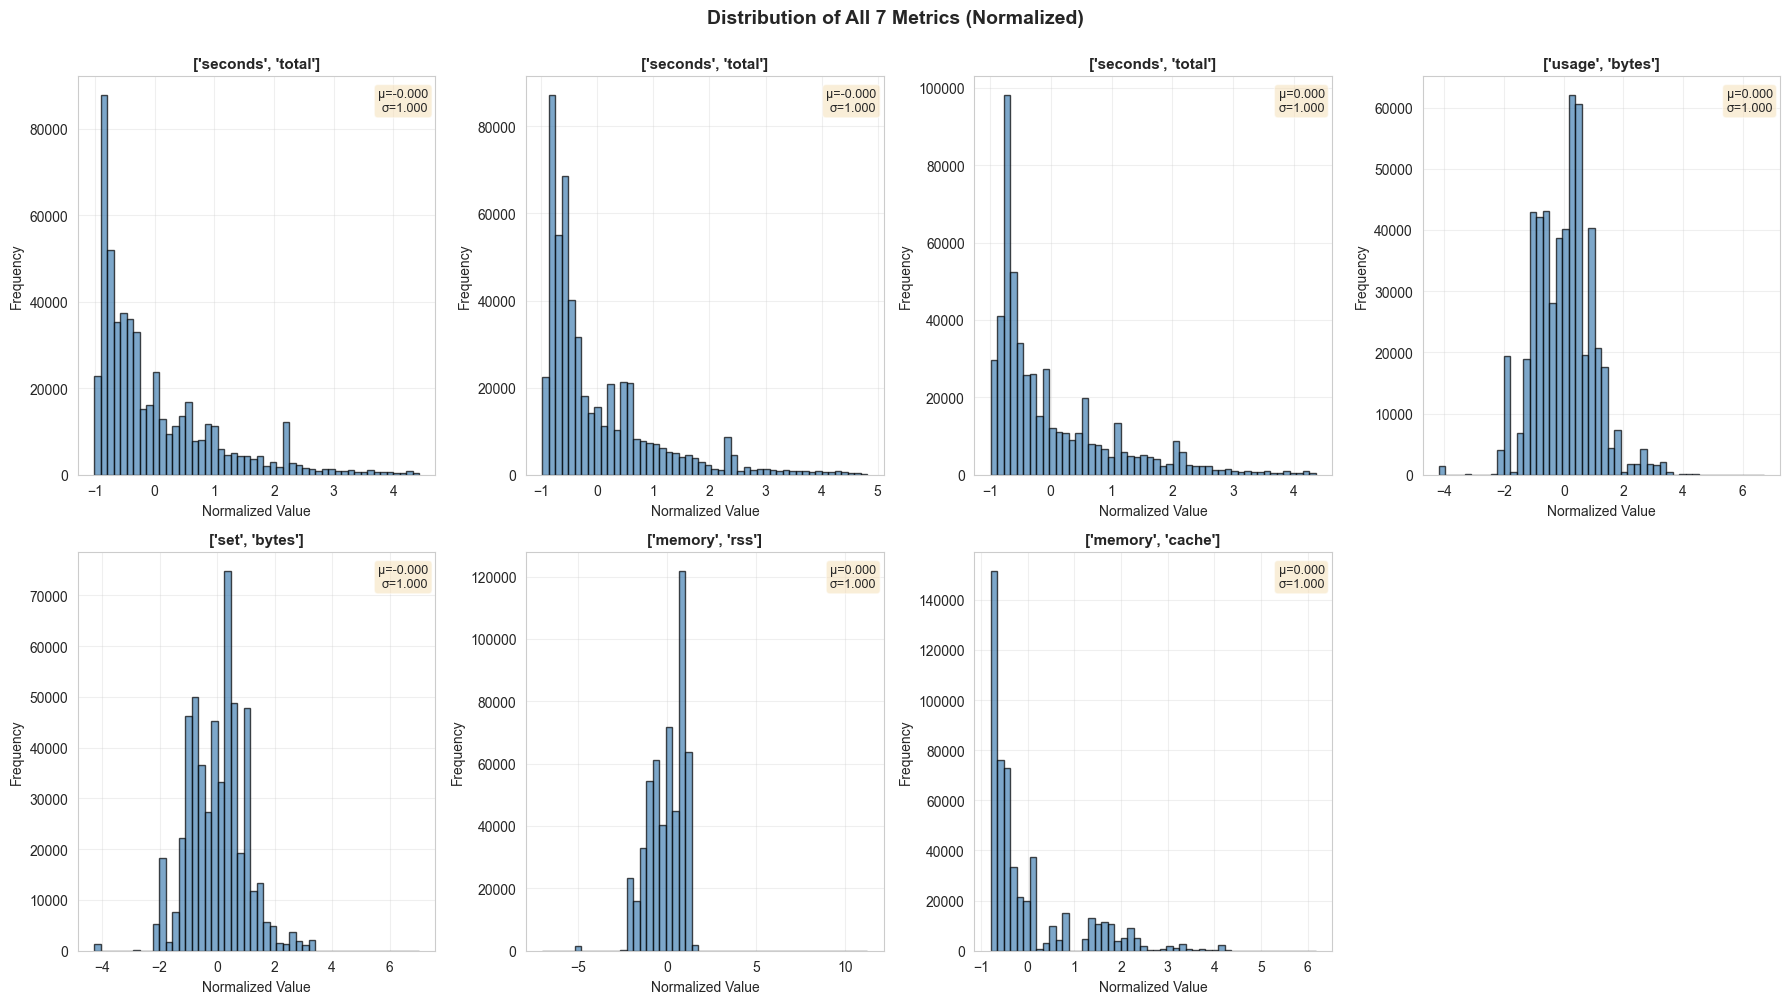

In [7]:
# Distribution plots for each metric
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(all_metrics):
    ax = axes[idx]
    data = df[metric]
    
    ax.hist(data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{metric.split("_")[-2:]}'[:30], fontsize=11, fontweight='bold')
    ax.set_xlabel('Normalized Value')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    
    # Add stats
    stats_text = f'μ={data.mean():.3f}\nσ={data.std():.3f}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide unused subplot
axes[7].axis('off')

plt.suptitle('Distribution of All 7 Metrics (Normalized)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Per-Container Time Series (Sample Containers)

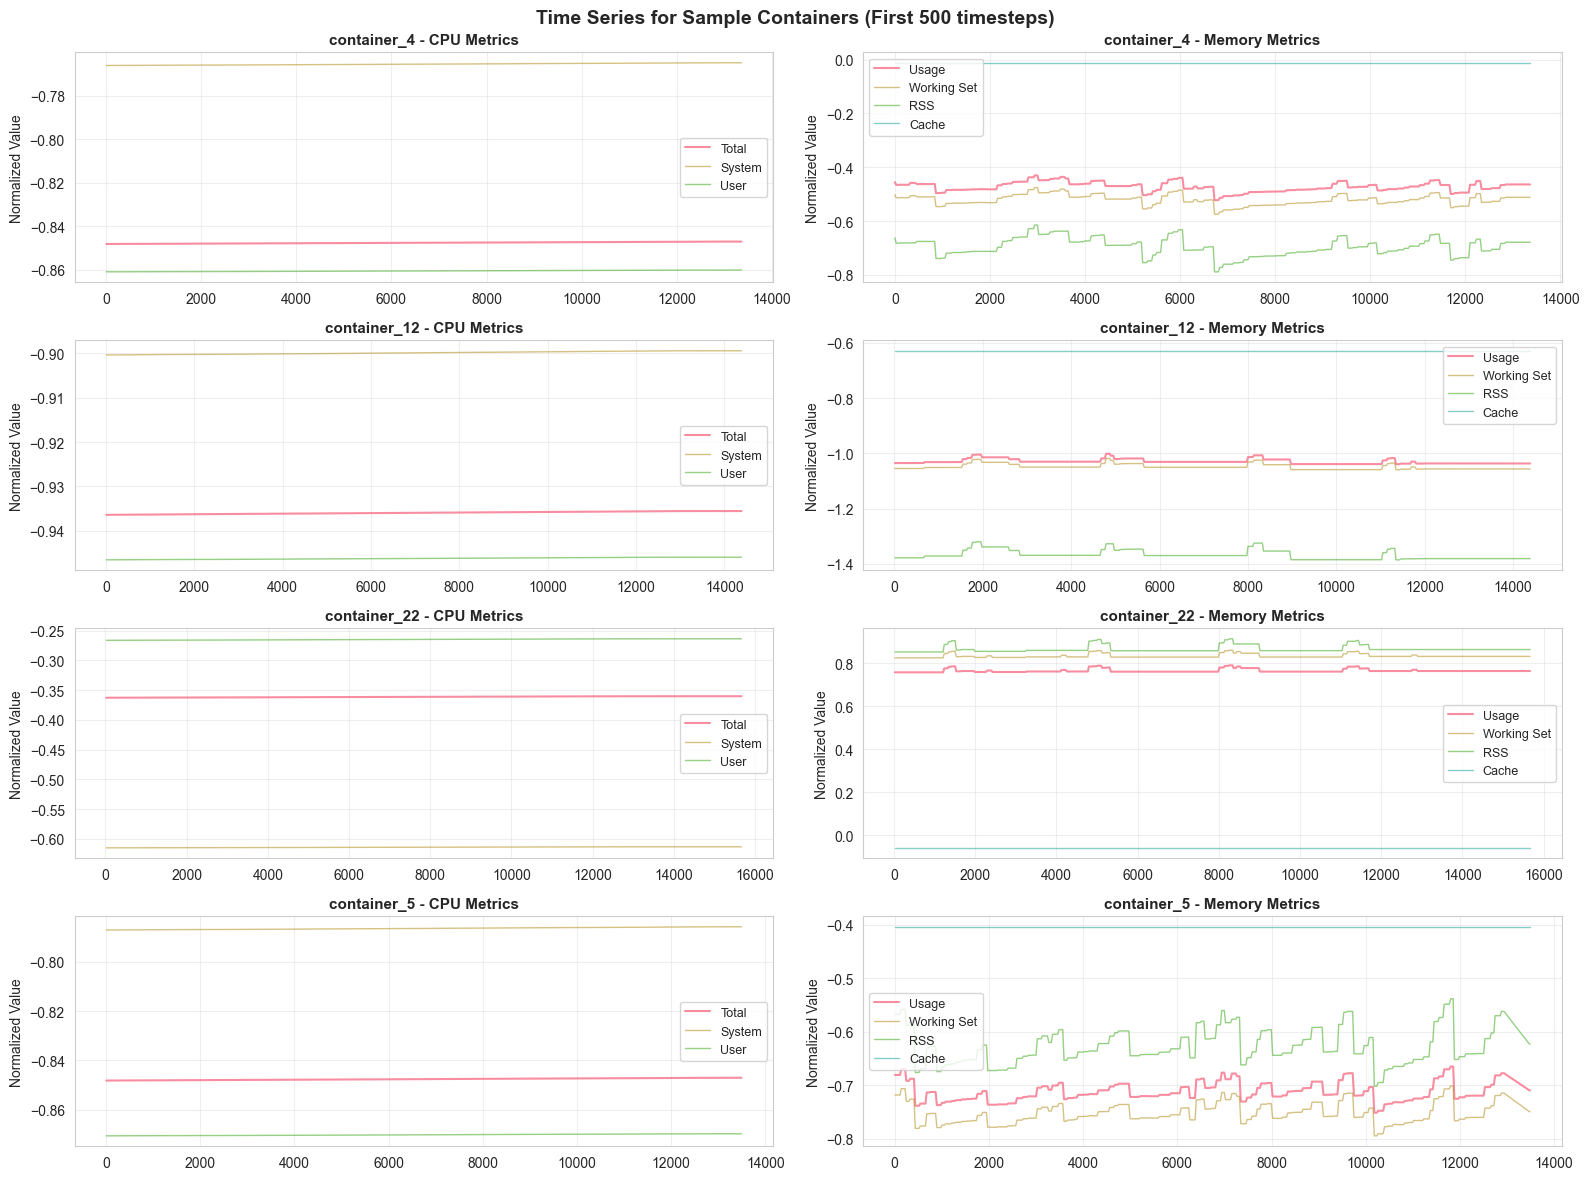

Sample containers: ['container_4', 'container_12', 'container_22', 'container_5']


In [8]:
# Select 4 random containers for visualization
sample_containers = np.random.choice(df['new_container_id'].unique(), 4, replace=False)

fig, axes = plt.subplots(4, 2, figsize=(16, 12))

for row, container in enumerate(sample_containers):
    container_data = df[df['new_container_id'] == container].sort_values('timestamp').head(500)
    
    # CPU plot
    ax = axes[row, 0]
    ax.plot(container_data['container_cpu_usage_seconds_total'], label='Total', linewidth=1.5, alpha=0.8)
    ax.plot(container_data['container_cpu_system_seconds_total'], label='System', linewidth=1, alpha=0.6)
    ax.plot(container_data['container_cpu_user_seconds_total'], label='User', linewidth=1, alpha=0.6)
    ax.set_title(f'{container} - CPU Metrics', fontsize=11, fontweight='bold')
    ax.set_ylabel('Normalized Value')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Memory plot
    ax = axes[row, 1]
    ax.plot(container_data['container_memory_usage_bytes'], label='Usage', linewidth=1.5, alpha=0.8)
    ax.plot(container_data['container_memory_working_set_bytes'], label='Working Set', linewidth=1, alpha=0.6)
    ax.plot(container_data['container_memory_rss'], label='RSS', linewidth=1, alpha=0.6)
    ax.plot(container_data['container_memory_cache'], label='Cache', linewidth=1, alpha=0.6)
    ax.set_title(f'{container} - Memory Metrics', fontsize=11, fontweight='bold')
    ax.set_ylabel('Normalized Value')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Time Series for Sample Containers (First 500 timesteps)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Sample containers: {list(sample_containers)}')

## Metric Correlation Analysis

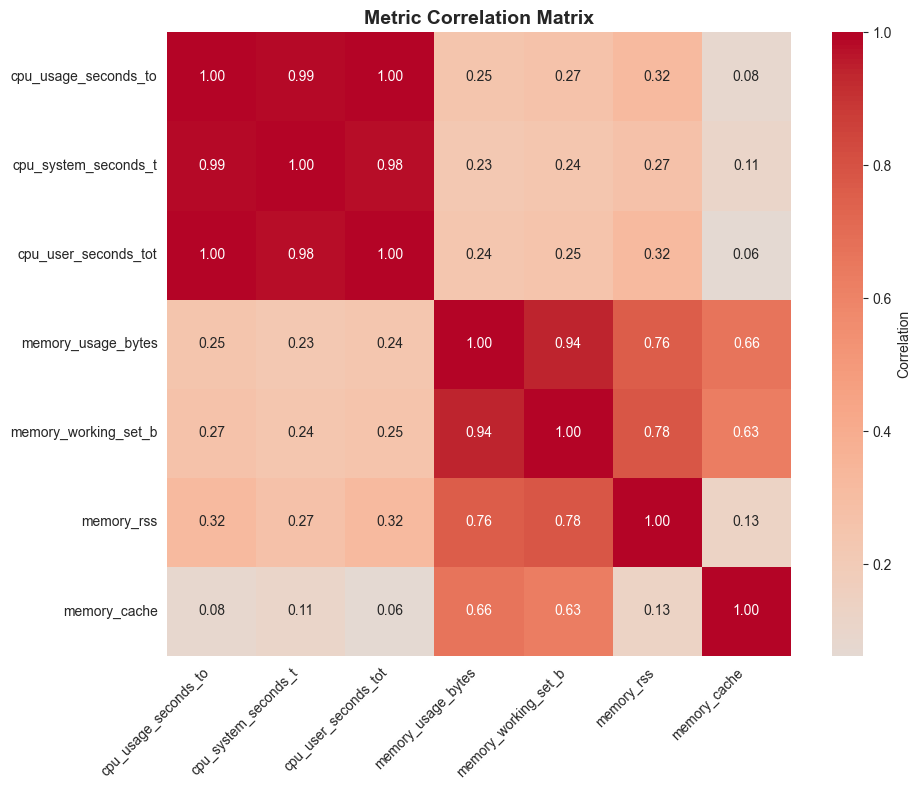


✓ Strong correlations indicate inter-metric dependencies
✓ Multi-metric modeling will capture these relationships


In [9]:
# Correlation matrix for all metrics
corr_matrix = df[all_metrics].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={'label': 'Correlation'}, 
            xticklabels=[m.replace('container_', '')[:20] for m in all_metrics],
            yticklabels=[m.replace('container_', '')[:20] for m in all_metrics])
ax.set_title('Metric Correlation Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\n✓ Strong correlations indicate inter-metric dependencies')
print('✓ Multi-metric modeling will capture these relationships')

## Data Quality Verification

In [10]:
print('='*80)
print('DATA QUALITY CHECKS')
print('='*80)

# Null values
null_counts = df[all_metrics].isnull().sum()
print(f'\n1. Null Values:')
if null_counts.sum() == 0:
    print('   ✓ No null values across all metrics')
else:
    print(f'   ✗ Found {null_counts.sum()} nulls')
    print(null_counts[null_counts > 0])

# Duplicates
print(f'\n2. Duplicates:')
dup_count = df.duplicated(subset=['timestamp', 'new_container_id']).sum()
print(f'   Rows with same timestamp & container: {dup_count:,}')
print(f'   (Expected: ~96k duplicates due to container merging)')

# Timestamp continuity
print(f'\n3. Timestamp Continuity:')
unique_ts = df['timestamp'].nunique()
total_rows = len(df)
print(f'   Unique timestamps: {unique_ts:,}')
print(f'   Total rows: {total_rows:,}')
print(f'   Avg rows per timestamp: {total_rows / unique_ts:.1f} (expected: ~27 containers)')

# Values in valid range
print(f'\n4. Normalized Value Ranges:')
print(f'   ✓ After z-score normalization, values should be roughly in [-3, 3]')
for metric in all_metrics:
    min_val = df[metric].min()
    max_val = df[metric].max()
    out_of_range = ((df[metric] < -5) | (df[metric] > 5)).sum()
    print(f'   {metric[:35]:<35s}: [{min_val:7.2f}, {max_val:7.2f}] (outliers: {out_of_range:,})')

DATA QUALITY CHECKS

1. Null Values:
   ✓ No null values across all metrics

2. Duplicates:
   Rows with same timestamp & container: 132,334
   (Expected: ~96k duplicates due to container merging)

3. Timestamp Continuity:
   Unique timestamps: 14,868
   Total rows: 533,338
   Avg rows per timestamp: 35.9 (expected: ~27 containers)

4. Normalized Value Ranges:
   ✓ After z-score normalization, values should be roughly in [-3, 3]
   container_cpu_usage_seconds_total  : [  -1.01,    4.43] (outliers: 0)
   container_cpu_system_seconds_total : [  -0.98,    4.82] (outliers: 0)
   container_cpu_user_seconds_total   : [  -0.99,    4.35] (outliers: 0)
   container_memory_usage_bytes       : [  -4.19,    6.70] (outliers: 76)
   container_memory_working_set_bytes : [  -4.27,    7.03] (outliers: 76)
   container_memory_rss               : [  -7.00,   11.27] (outliers: 226)
   container_memory_cache             : [  -0.79,    6.17] (outliers: 168)


## Per-Case Metric Overview

In [11]:
# Compare metrics across cases
print('='*100)
print('METRICS BY CASE (Showing mean and std after normalization)')
print('='*100)

for case in sorted(df['case_source'].unique()):
    case_df = df[df['case_source'] == case]
    print(f'\n{case.upper()}')
    print('-'*100)
    print(f'{"Metric":<40s} {"Mean":>12s} {"Std":>12s} {"Min":>12s} {"Max":>12s}')
    print('-'*100)
    
    for metric in all_metrics:
        mean = case_df[metric].mean()
        std = case_df[metric].std()
        min_val = case_df[metric].min()
        max_val = case_df[metric].max()
        print(f'{metric:<40s} {mean:12.4f} {std:12.4f} {min_val:12.4f} {max_val:12.4f}')

METRICS BY CASE (Showing mean and std after normalization)

COMPLEX_CASE1
----------------------------------------------------------------------------------------------------
Metric                                           Mean          Std          Min          Max
----------------------------------------------------------------------------------------------------
container_cpu_usage_seconds_total             -0.0000       1.0000      -0.8430       4.4310
container_cpu_system_seconds_total             0.0000       1.0000      -0.7861       4.8156
container_cpu_user_seconds_total               0.0000       1.0000      -0.7676       4.3544
container_memory_usage_bytes                   0.0000       1.0000      -4.1881       5.6471
container_memory_working_set_bytes            -0.0000       1.0000      -4.2719       5.8738
container_memory_rss                           0.0000       1.0000      -4.9573       8.4152
container_memory_cache                         0.0000       1.0000      -

## Final Readiness Check

In [12]:
print('='*80)
print('FEATURE VERIFICATION SUMMARY')
print('='*80)

checks = {
    '✓ All 7 metrics present': len([m for m in all_metrics if m in df.columns]) == 7,
    '✓ 27 unique containers': df['new_container_id'].nunique() == 27,
    '✓ 4 cases merged': df['case_source'].nunique() == 4,
    '✓ No null values': df.isnull().sum().sum() == 0,
    '✓ Z-score normalized (mean≈0, std≈1)': abs(df[all_metrics].mean().mean()) < 0.01 and abs(df[all_metrics].std().mean() - 1.0) < 0.1,
    '✓ Continuous timestamps': len(df['timestamp'].unique()) > 100,
    '✓ 533k+ rows': len(df) > 500000,
}

for check, result in checks.items():
    status = '✓ PASS' if result else '✗ FAIL'
    print(f'{check:<50s} {status}')

all_pass = all(checks.values())
print('\n' + '='*80)
if all_pass:
    print('✓ ALL FEATURES VERIFIED - READY FOR SEQUENCE GENERATION')
else:
    print('✗ SOME CHECKS FAILED - REVIEW ABOVE')
print('='*80)

FEATURE VERIFICATION SUMMARY
✓ All 7 metrics present                            ✓ PASS
✓ 27 unique containers                             ✓ PASS
✓ 4 cases merged                                   ✓ PASS
✓ No null values                                   ✓ PASS
✓ Z-score normalized (mean≈0, std≈1)               ✓ PASS
✓ Continuous timestamps                            ✓ PASS
✓ 533k+ rows                                       ✓ PASS

✓ ALL FEATURES VERIFIED - READY FOR SEQUENCE GENERATION
